# Projet d'Analyse de données



In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
#from skimpy import skim
import seaborn as sns 
%matplotlib inline

## Introduction


## Présentation du jeu de données 

In [6]:
# Liste des variables originales et leurs descriptions
variables = {
    "Date": "Date du jour de la donnée",
    "Service": "Type de service ou train",
    "Gare de départ": "Gare de départ",
    "Gare d'arrivée": "Gare d'arrivée",
    "Durée moyenne du trajet": "Durée moyenne du trajet",
    "Nombre de circulations prévues": "Nombre de circulations prévues",
    "Nombre de trains annulés": "Nombre de trains annulés",
    "Nombre de trains en retard au départ": "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ": "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ": "Retard moyen de tous les trains au départ",
    "Nombre de trains en retard à l'arrivée": "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée": "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée": "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min": "Nombre de trains en retard de plus de 15 min",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "Retard moyen > 15 min si concurrence aérienne",
    "Nombre trains en retard > 30min": "Nombre de trains en retard de plus de 30 min",
    "Nombre trains en retard > 60min": "Nombre de trains en retard de plus de 60 min",
    "Prct retard pour causes externes": "Pourcentage de retard pour causes externes",
    "Prct retard pour cause infrastructure": "Pourcentage de retard pour causes infrastructure",
    "Prct retard pour cause gestion trafic": "Pourcentage de retard pour causes gestion trafic",
    "Prct retard pour cause matériel roulant": "Pourcentage de retard pour causes matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "Pourcentage de retard pour causes gestion gare / réutilisation matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence": "Pourcentage de retard pour causes affluence voyageurs"
}

# transformer noms plus courts
short_names = {
    "Date": "date",
    "Service": "service",
    "Gare de départ": "dep_station",
    "Gare d'arrivée": "arr_station",
    "Durée moyenne du trajet": "avg_duration",
    "Nombre de circulations prévues": "planned_trains",
    "Nombre de trains annulés": "cancelled_trains",
    "Nombre de trains en retard au départ": "dep_late_trains",
    "Retard moyen des trains en retard au départ": "dep_avg_late",
    "Retard moyen de tous les trains au départ": "dep_avg_all",
    "Nombre de trains en retard à l'arrivée": "arr_late_trains",
    "Retard moyen des trains en retard à l'arrivée": "arr_avg_late",
    "Retard moyen de tous les trains à l'arrivée": "arr_avg_all",
    "Nombre trains en retard entre 15 et 30 min": "late_15",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "late_15_air",
    "Nombre trains en retard entre 30 et 60 min": "late_30",
    "Nombre trains en retard > 60min": "late_60",
    "Prct retard pour causes externes": "pct_external",
    "Prct retard pour cause infrastructure": "pct_infra",
    "Prct retard pour cause gestion trafic": "pct_traffic",
    "Prct retard pour cause matériel roulant": "pct_rolling",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "pct_station",
    "Prct retard pour cause prise en compte voyageurs (affluence": "pct_passengers"
}

# création DataFrame pour affichage 
df_vars = pd.DataFrame({
    "Variables renommées": [short_names[k] for k in variables.keys()],
    "Description": [variables[k] for k in variables.keys()]
})

print("Chaque individu représente un mois, pour lesquels on observe 23 variables")
display(df_vars.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left')])]
))

#attention, je n'ai pas mis les 5 colonnes qui ont beaucoup de données manquantes
#a adapter quand nettoyage données est fait 

Chaque individu représente un mois, pour lesquels on observe 23 variables


,Variables renommées,Description
0,date,Date du jour de la donnée
1,service,Type de service ou train
2,dep_station,Gare de départ
3,arr_station,Gare d'arrivée
4,avg_duration,Durée moyenne du trajet
5,planned_trains,Nombre de circulations prévues
6,cancelled_trains,Nombre de trains annulés
7,dep_late_trains,Nombre de trains en retard au départ
8,dep_avg_late,Retard moyen des trains en retard au départ
9,dep_avg_all,Retard moyen de tous les trains au départ


In [58]:
data['moy_retard_train_deja_retard'] = np.where(
    data['dep_late_trains'] > 0, 
    (data['dep_avg_all'] * data['planned_trains']) / data['dep_late_trains'], 
    0  # Valeur par défaut si aucun train n'est en retard
)

In [59]:
data.dtypes

date                            category
service                         category
dep_station                     category
arr_station                     category
avg_duration                       int64
planned_trains                     int64
cancelled_trains                   int64
dep_late_trains                    int64
dep_avg_late                     float64
dep_avg_all                      float64
arr_late_trains                    int64
arr_avg_late                     float64
arr_avg_all                      float64
late_15                            int64
late_15_air                      float64
late_30                            int64
late_60                            int64
pct_external                     float64
pct_infra                        float64
pct_traffic                      float64
pct_rolling                      float64
pct_station                      float64
pct_passengers                   float64
moy_retard_train_deja_retard     float64
dtype: object

## Prise en charge des données


In [7]:
data = pd.read_excel('regularite-mensuelle-tgv-aqst.ods',engine='odf')
data = data.rename(columns=short_names)


display( 
    data.head().style.background_gradient(cmap='BuPu')
)

/opt/anaconda3/lib/python3.11/site-packages/pandas/io/formats/style.py:3819: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/opt/anaconda3/lib/python3.11/site-packages/pandas/io/formats/style.py:3820: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,Commentaire annulations,dep_late_trains,dep_avg_late,dep_avg_all,Commentaire retards au départ,arr_late_trains,arr_avg_late,arr_avg_all,Commentaire retards à l'arrivée,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers,gestions PSH,correspondances)
0,2025-01,International,GENEVE,PARIS LYON,193,238,1,nan,216,3.182485,2.979606,nan,19,42.776316,4.399015,nan,19,42.776316,0,13,10.000000,60.000000,20.000000,5.000000,5.000000,0.000000,nan,nan
1,2025-01,International,ITALIE,PARIS LYON,535,30,0,nan,14,2.713095,1.366667,nan,5,31.940000,8.500556,nan,5,31.940000,0,1,20.000000,0.000000,40.000000,40.000000,0.000000,0.000000,nan,nan
2,2025-01,National,BESANCON FRANCHE COMTE TGV,PARIS LYON,133,183,0,nan,30,17.588889,2.555373,nan,24,52.936111,6.397359,nan,20,60.764167,0,14,20.000000,48.000000,16.000000,12.000000,0.000000,4.000000,nan,nan
3,2025-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,145,1029,0,nan,317,18.564090,5.589828,nan,180,40.713704,8.774603,nan,132,50.812500,0,69,20.000000,20.555556,29.444444,16.111111,6.111111,7.777778,nan,nan
4,2025-01,National,BREST,PARIS MONTPARNASSE,232,294,7,nan,20,11.966667,0.835714,nan,30,37.223889,4.704413,nan,30,37.223889,0,13,32.258065,25.806452,16.129032,9.677419,9.677419,6.451613,nan,nan


In [8]:
cols_to_drop = [
    c for c in data.columns 
    if c.startswith("Commentaire") 
    or " gestions PSH" in c 
    or "correspondances)" in c
]
data = data.drop(columns=cols_to_drop)
display(
    data.head().style.background_gradient(cmap="BuPu")
)
len(data)

data['date'] = data['date'].astype('category')
data['service'] = data['service'].astype('category')
data['dep_station'] = data['dep_station'].astype('category')
data['arr_station'] = data['arr_station'].astype('category')
skim(data)

,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,arr_late_trains,arr_avg_late,arr_avg_all,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers
0,2025-01,International,GENEVE,PARIS LYON,193,238,1,216,3.182485,2.979606,19,42.776316,4.399015,19,42.776316,0,13,10.000000,60.000000,20.000000,5.000000,5.000000,0.000000
1,2025-01,International,ITALIE,PARIS LYON,535,30,0,14,2.713095,1.366667,5,31.940000,8.500556,5,31.940000,0,1,20.000000,0.000000,40.000000,40.000000,0.000000,0.000000
2,2025-01,National,BESANCON FRANCHE COMTE TGV,PARIS LYON,133,183,0,30,17.588889,2.555373,24,52.936111,6.397359,20,60.764167,0,14,20.000000,48.000000,16.000000,12.000000,0.000000,4.000000
3,2025-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,145,1029,0,317,18.564090,5.589828,180,40.713704,8.774603,132,50.812500,0,69,20.000000,20.555556,29.444444,16.111111,6.111111,7.777778
4,2025-01,National,BREST,PARIS MONTPARNASSE,232,294,7,20,11.966667,0.835714,30,37.223889,4.704413,30,37.223889,0,13,32.258065,25.806452,16.129032,9.677419,9.677419,6.451613


NameError: name 'skim' is not defined

## Exploration élémentaire : analyse descriptive

### Analyse descriptive unidimensionnelles

#### Pourcentage moyen de retard en fonction des causes 

In [9]:
#calcule le % moyen de retard pour causes externes
external_mean = data['pct_external'].mean()
print(f"Pourcentage moyen de retard pour causes externes: {external_mean:.2f}%")

#calcule le % moyen de retard pour causes infrastruture
infrastruture_mean = data['pct_infra'].mean()
print(f"Pourcentage moyen de retard pour causes infrastruture: {infrastruture_mean:.2f}%")

#calcule le % moyen de retard pour causes gestion traffic
traffic_mean = data['pct_traffic'].mean()
print(f"Pourcentage moyen de retard pour causes gestion traffic: {traffic_mean:.2f}%")

#calcule le % moyen de retard pour causes matériel roulant
rolling_mean = data['pct_rolling'].mean()
print(f"Pourcentage moyen de retard pour causes matériel roulant: {rolling_mean:.2f}%")

#calcule le % moyen de retard pour causes gestion gare / réutilisation matériel
station_mean = data['pct_station'].mean()
print(f"Pourcentage moyen de retard pour causes gestion gare / réutilisation matériel: {station_mean:.2f}%")

#calcule le % moyen de retard pour causes prise en compte voyageurs (affluence)
passengers_mean = data['pct_passengers'].mean()
print(f"Pourcentage moyen de retard pour causes prise en compte voyageurs (affluence): {passengers_mean:.2f}%")

Pourcentage moyen de retard pour causes externes: 19.42%
Pourcentage moyen de retard pour causes infrastruture: 22.09%
Pourcentage moyen de retard pour causes gestion traffic: 23.28%
Pourcentage moyen de retard pour causes matériel roulant: 18.00%
Pourcentage moyen de retard pour causes gestion gare / réutilisation matériel: 8.56%
Pourcentage moyen de retard pour causes prise en compte voyageurs (affluence): 7.73%


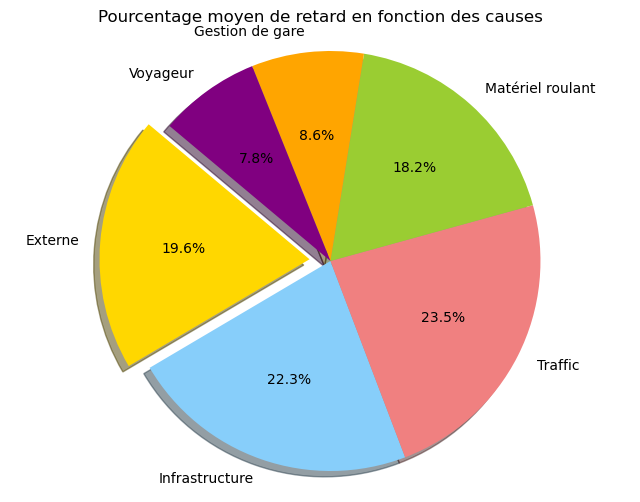

In [43]:
causes = ['Externe', 'Infrastructure', 'Traffic', 'Matériel roulant', 'Gestion de gare','Voyageur']
tailles = [external_mean, infrastruture_mean, traffic_mean, rolling_mean, station_mean,passengers_mean]  # Les parts (en pourcentage ou valeurs brutes)
couleurs = ['gold', 'lightskyblue', 'lightcoral', 'yellowgreen','orange','purple']
#explode = (0.1, 0, 0, 0,0,0)  # On "extrait" la première part (Externe) pour l'effet visuel

plt.figure(figsize=(8, 6))
plt.pie(tailles, 
        labels=causes, 
       #explode=explode,
        colors=couleurs,
        autopct='%1.1f%%', # Affiche le pourcentage avec une décimale
        shadow=True, 
        startangle=140) # Oriente le début du cercle

# 3. Personnalisation
plt.title("Pourcentage moyen de retard en fonction des causes")
plt.axis('equal')  # Assure que le camembert est bien un cercle et non une ellipse

# 4. Affichage
plt.show()

#### Min Max et Médiane 

In [10]:
# Liste des colonnes pour les causes de retard
causes = ['pct_external', 'pct_infra', 'pct_traffic', 'pct_rolling', 'pct_station', 'pct_passengers']

# Parcours de chaque cause pour afficher min, médiane et max
for cause in causes:
    min_val = data[cause].min()
    median_val = data[cause].median()
    max_val = data[cause].max()
    print(f"{cause}: min = {min_val:.2f}%, médiane = {median_val:.2f}%, max = {max_val:.2f}%")

pct_external: min = 0.00%, médiane = 17.39%, max = 100.00%
pct_infra: min = 0.00%, médiane = 20.69%, max = 100.00%
pct_traffic: min = 0.00%, médiane = 22.22%, max = 100.00%
pct_rolling: min = 0.00%, médiane = 16.35%, max = 100.00%
pct_station: min = 0.00%, médiane = 7.21%, max = 66.67%
pct_passengers: min = 0.00%, médiane = 6.45%, max = 66.67%


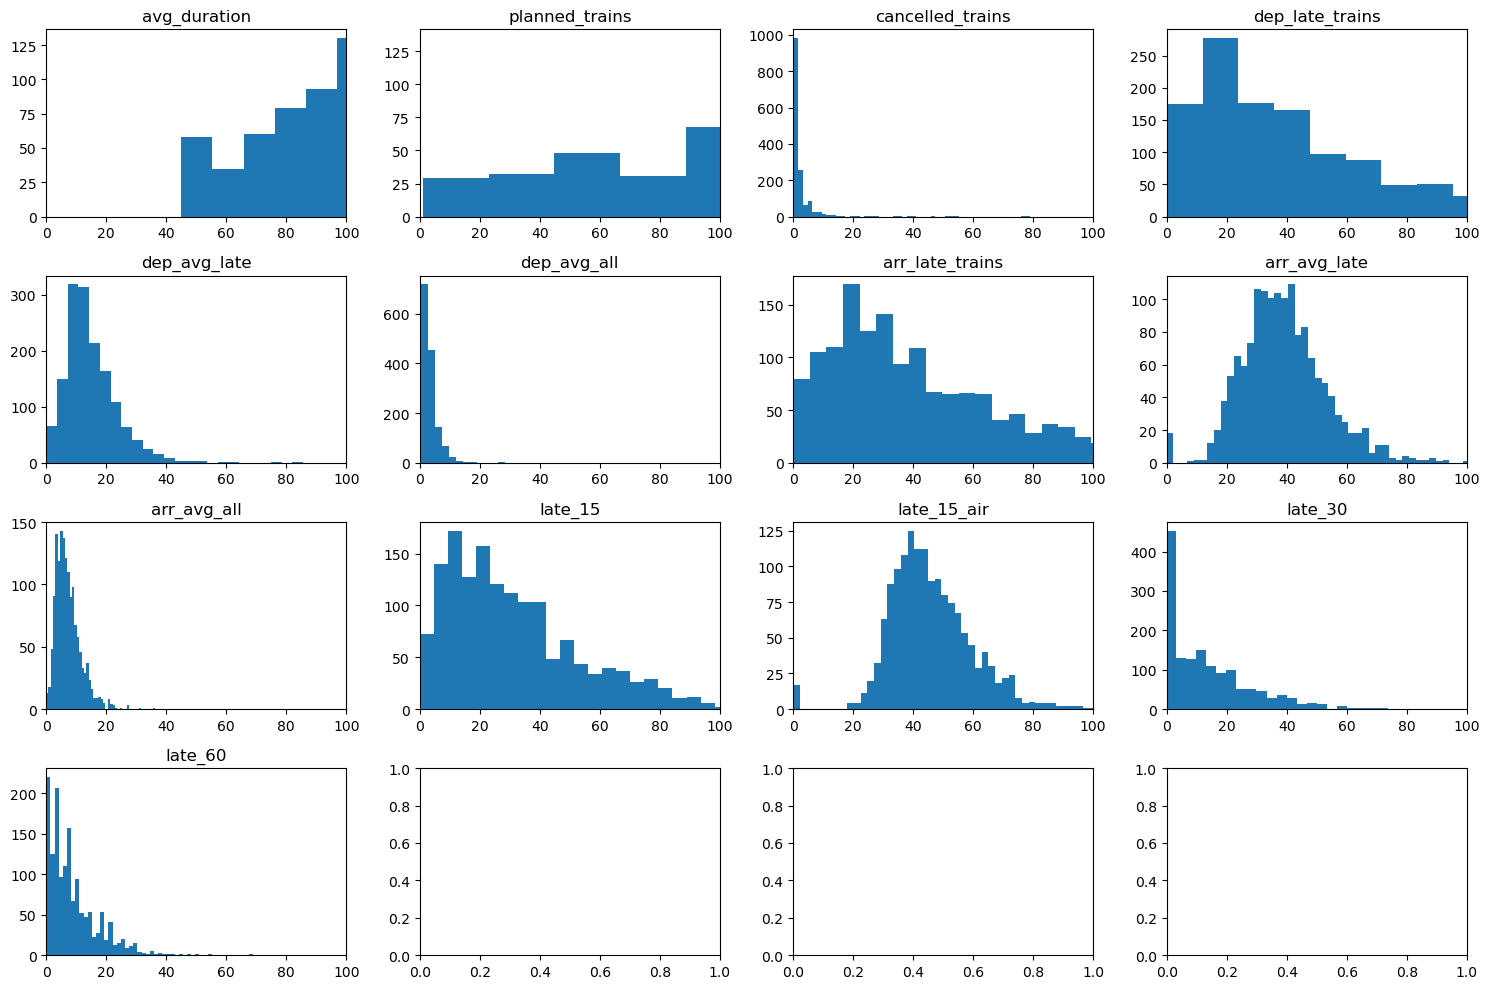

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(15, 10))

columns = ["avg_duration", "planned_trains", "cancelled_trains","dep_late_trains", "dep_avg_late", "dep_avg_all", "arr_late_trains", "arr_avg_late", "arr_avg_all", "late_15", "late_15_air", "late_30", "late_60"]
axes_flat = axes.flatten()

for i, col in enumerate(columns):
    axes_flat[i].set_xlim(0, 100)
    axes_flat[i].hist(data[col], bins=50)
    axes_flat[i].set_title(col)


plt.tight_layout()
plt.show()

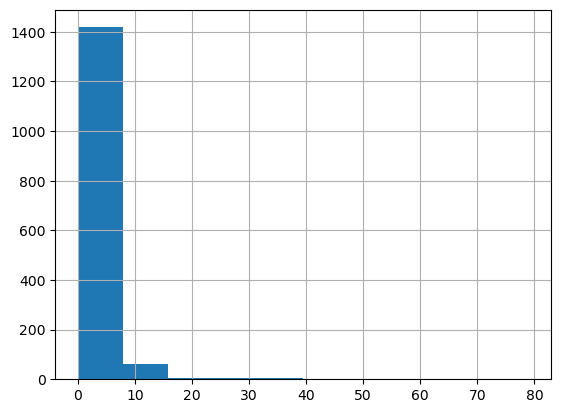

In [23]:
data["cancelled_trains"].hist()
plt.show()

plus de 1400 trajets ont étés annulés 7 trains, au dela de 15 annulations très peu de trains sont réannulés, sauf quelques cas particuliers (qui ont annulés 39 trains). 

In [42]:
bcp_trains_annules = data[data["cancelled_trains"] > 30]

# Afficher les résultats
for index, row in bcp_trains_annules.iterrows():
    print(f"Alerte : {row['dep_station']} - {row['arr_station']} - {row['date']} a annulé {row['cancelled_trains']} trains.")

Alerte : PARIS MONTPARNASSE - QUIMPER - 2025-01 a annulé 35 trains.
Alerte : PARIS MONTPARNASSE - VANNES - 2025-01 a annulé 39 trains.
Alerte : QUIMPER - PARIS MONTPARNASSE - 2025-01 a annulé 34 trains.
Alerte : VANNES - PARIS MONTPARNASSE - 2025-01 a annulé 38 trains.
Alerte : PARIS MONTPARNASSE - RENNES - 2025-02 a annulé 34 trains.
Alerte : PARIS MONTPARNASSE - VANNES - 2025-02 a annulé 40 trains.
Alerte : PARIS MONTPARNASSE - QUIMPER - 2025-02 a annulé 40 trains.
Alerte : QUIMPER - PARIS MONTPARNASSE - 2025-02 a annulé 47 trains.
Alerte : VANNES - PARIS MONTPARNASSE - 2025-02 a annulé 53 trains.
Alerte : PARIS MONTPARNASSE - TOURS - 2025-04 a annulé 77 trains.
Alerte : TOURS - PARIS MONTPARNASSE - 2025-04 a annulé 79 trains.
Alerte : TOULOUSE MATABIAU - PARIS MONTPARNASSE - 2025-05 a annulé 55 trains.
Alerte : PARIS MONTPARNASSE - TOULOUSE MATABIAU - 2025-05 a annulé 52 trains.


On constate que les trajets annulant plus de 30 trains vont par paire. Cela nous fait penser à d'éventuels travaux ou accidents sur chaque ligne.
Tout les trajets ayant annulés plus de 30 trains partent ou arrivent à paris montparnasse. Eventuels travaux a montparnasse.

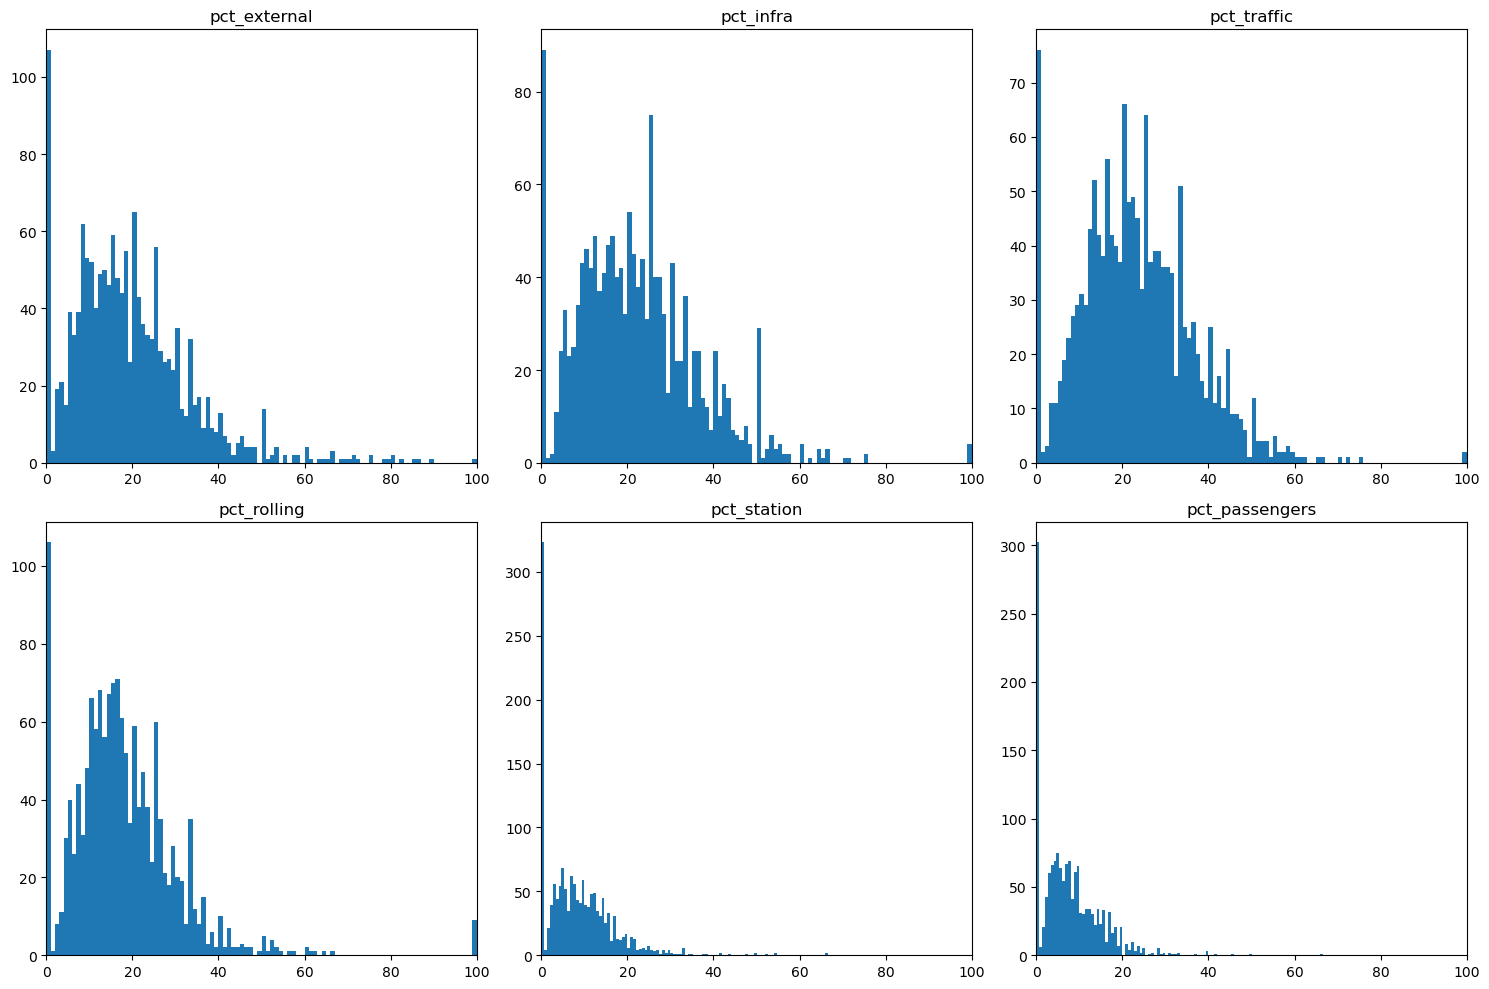

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

columns = ["pct_external", "pct_infra", "pct_traffic","pct_rolling", "pct_station", "pct_passengers"]
axes_flat = axes.flatten()

for i, col in enumerate(columns):
    axes_flat[i].set_xlim(0, 100)
    axes_flat[i].hist(data[col], bins=100)
    axes_flat[i].set_title(col)


plt.tight_layout()
plt.show()

### Analyse descriptive bidimensionnelles


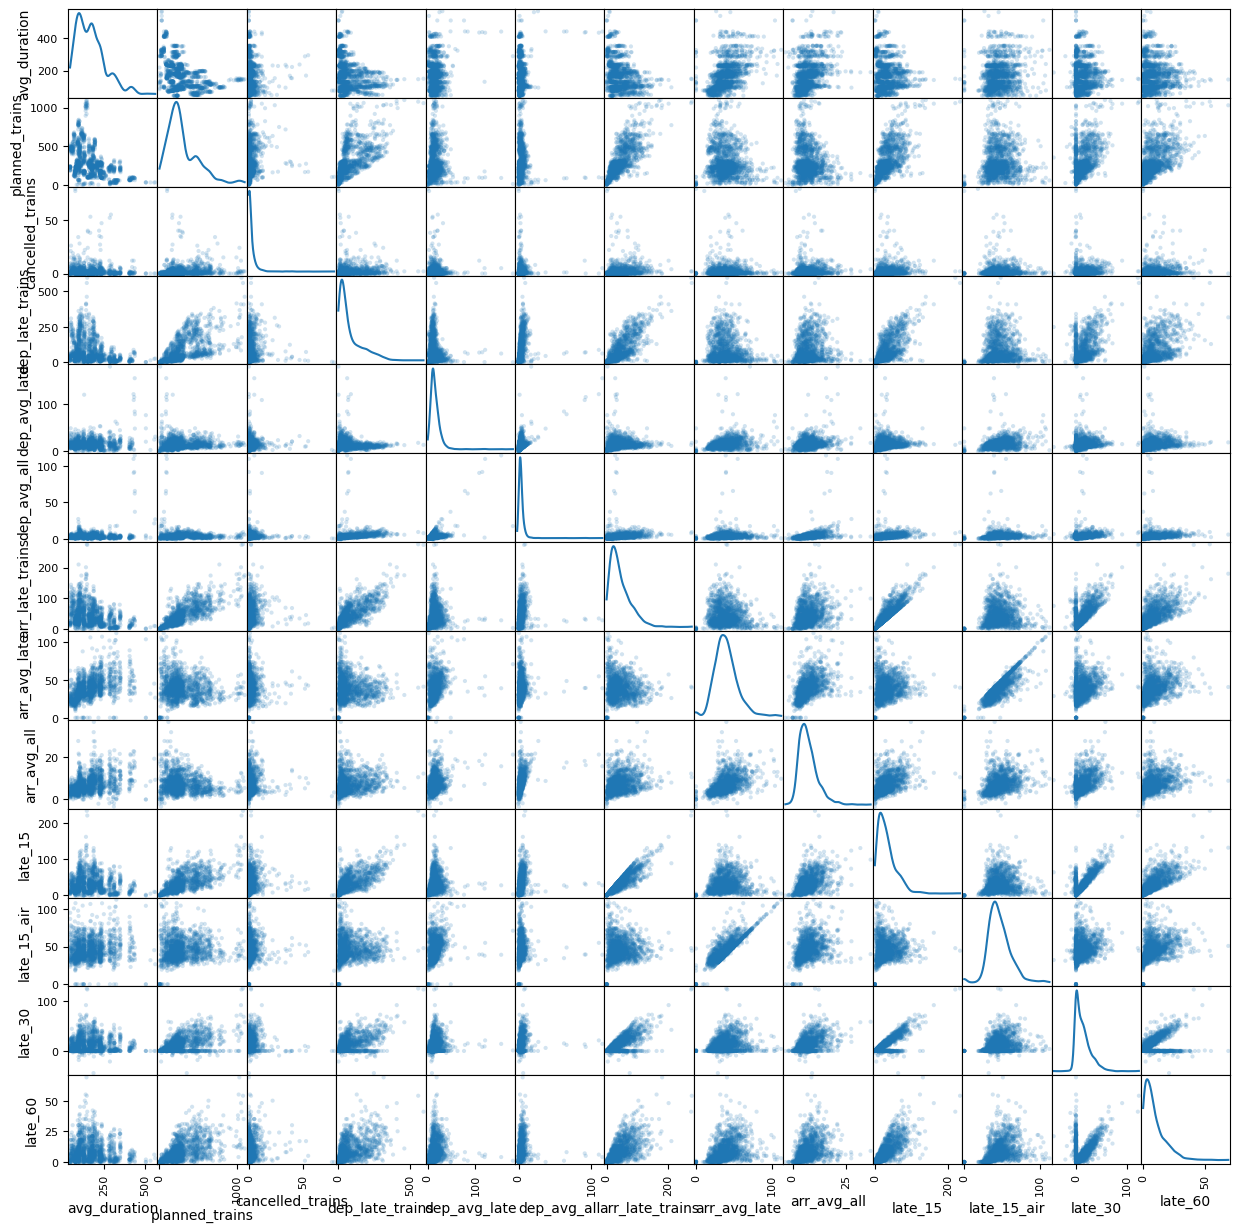

In [22]:
from pandas.plotting import scatter_matrix
scatter_matrix(data[["avg_duration", "planned_trains", "cancelled_trains","dep_late_trains", "dep_avg_late", "dep_avg_all", "arr_late_trains", "arr_avg_late", "arr_avg_all", "late_15", "late_15_air", "late_30", "late_60"]], alpha=0.2, 
               figsize=(15, 15), diagonal='kde')
plt.show()

In [56]:
data_quanti = data[[
    "avg_duration", "planned_trains", "cancelled_trains", "dep_late_trains",
    "dep_avg_late", "dep_avg_all", "arr_late_trains", "arr_avg_late",
    "arr_avg_all", "late_15", "late_15_air", "late_30", "late_60",
    "pct_external", "pct_infra", "pct_traffic", "pct_rolling",
    "pct_station", "pct_passengers"
]]
data_cause_duree = data[[ "late_15", "late_15_air", "late_30", "late_60", "pct_external", "pct_infra", "pct_traffic", "pct_rolling",
    "pct_station", "pct_passengers"]]

data_temps_de_trajet_vs_retard= data[["dep_late_trains",
    "dep_avg_late", "dep_avg_all", "arr_late_trains", "arr_avg_late",
    "arr_avg_all"]]

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

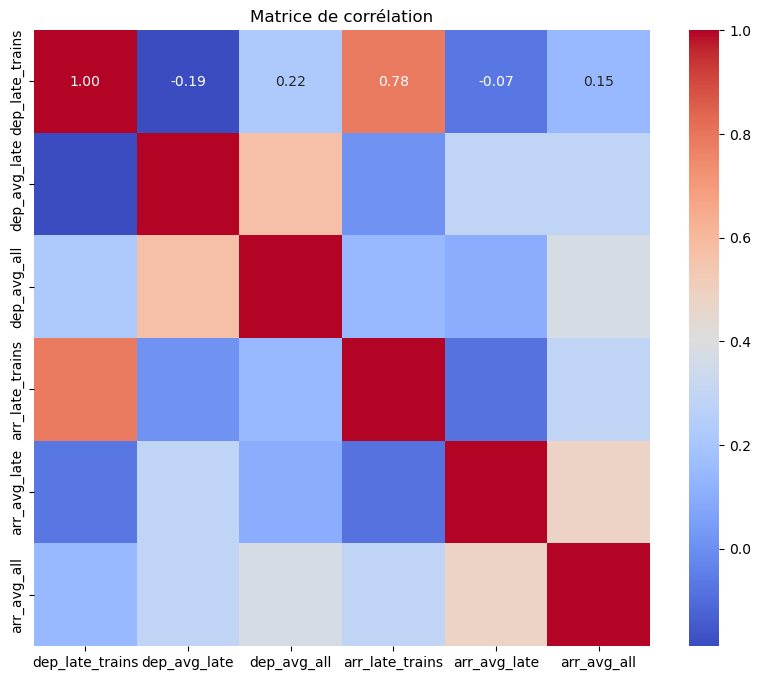

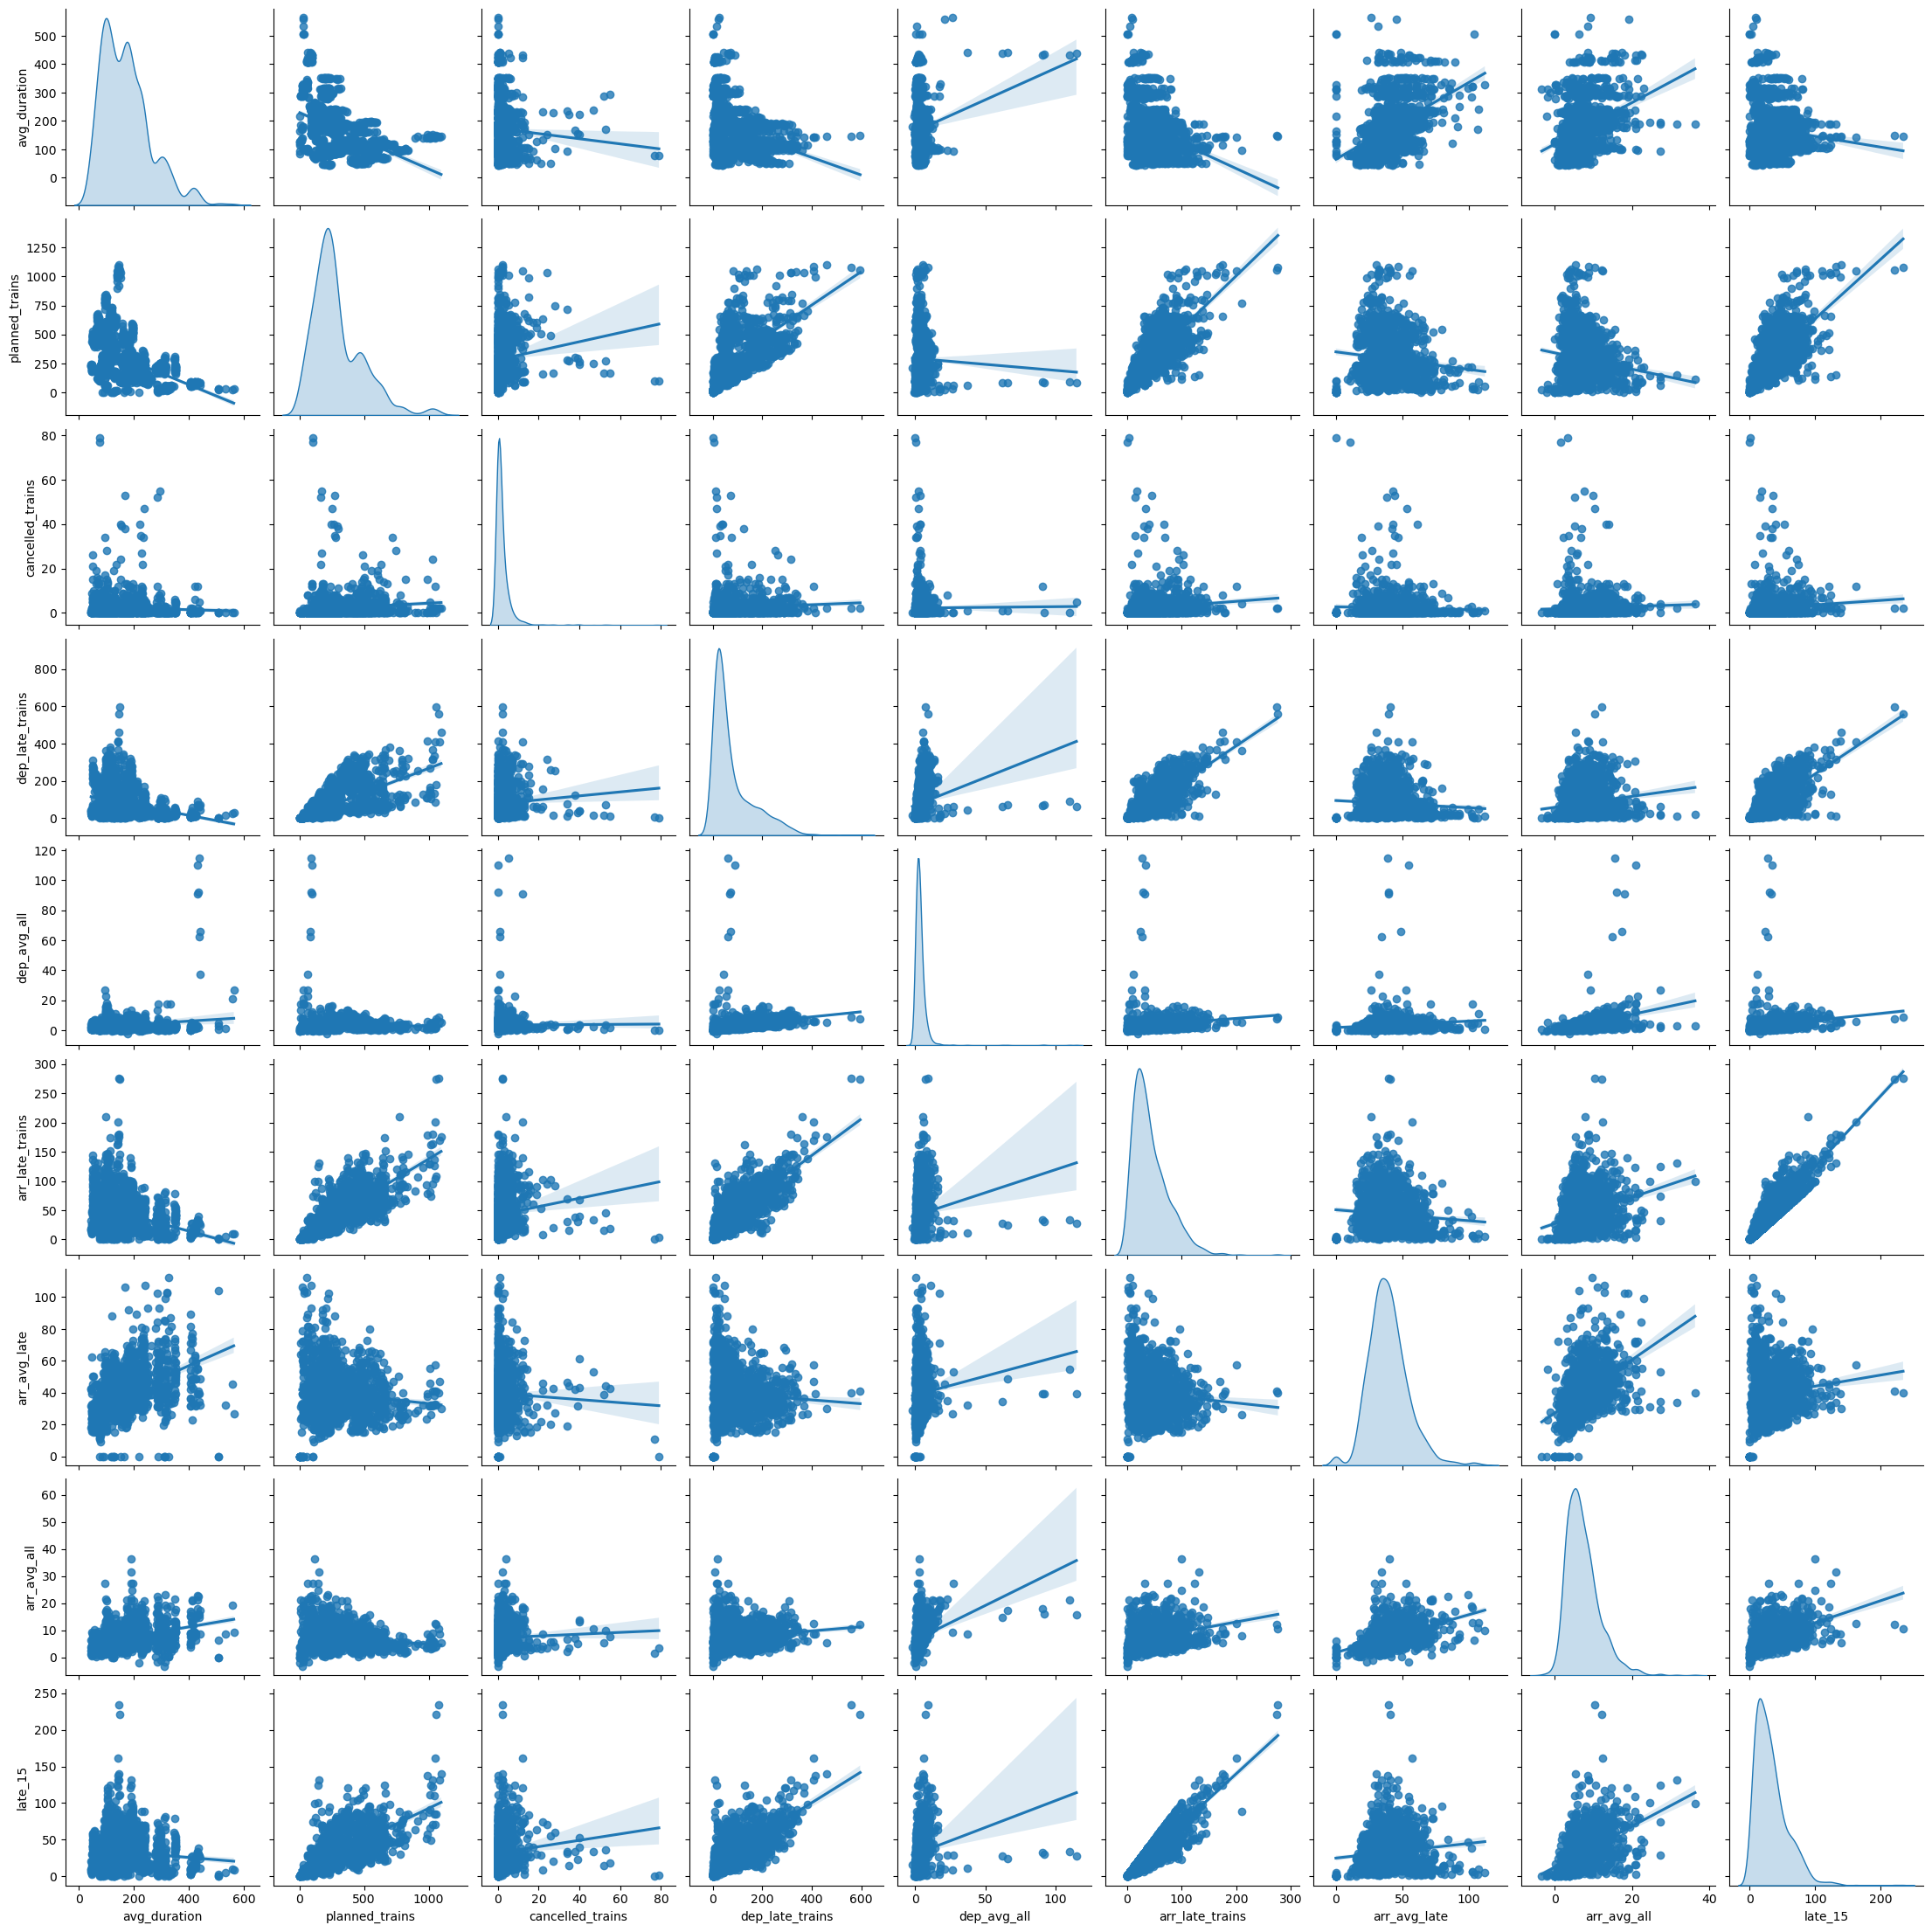

In [57]:
# On sélectionne les colonnes (index 1 à 3 et 5 à 9, car Python commence à 0)
cols = list(range(0, 4)) + list(range(5, 10))
#subset = data_quanti.iloc[:, cols]

# Calcul de la matrice de corrélation
corr = data_temps_de_trajet_vs_retard.corr()

# Création de la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matrice de corrélation")
sns.pairplot(subset, kind='reg', diag_kind='kde')
plt.show()

On constate que les causes de retard des trains ne sont pas liées au temps de retard du train. (en etudiant le dataset cause duree)
On constate que les trains qui partent en retard arrivent en retard (en etudiant le dataset data_temps_de_trajet_vs_retard).

In [63]:
tab=data['moy_retard_train_deja_retard']-data['dep_avg_late']
moy=0
for i in tab:
    moy+=i
moy=moy/1505
print(moy)



-0.8953102231111428


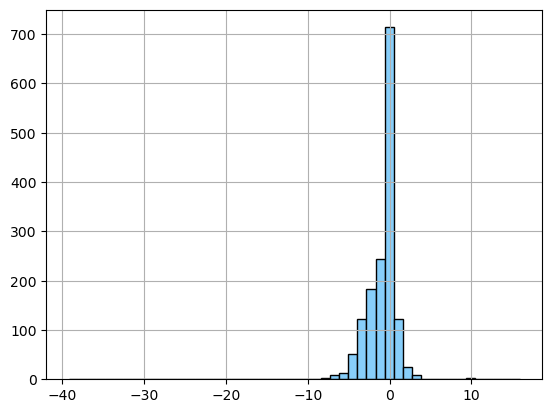

In [67]:
tab.hist(bins=50, color='lightskyblue', edgecolor='black')
plt.show()

On constate que la majorité des trains en retard au départ conservent leur retard. 
Il y a moins de trains qui rattrapent leur retard (droite) que de trains qui augmentent leur retard (gauche)

In [71]:
train_accumul_retard = data[tab < -10]

for index, row in train_accumul_retard.iterrows():
    print(f"Alerte : {row['dep_station']} - {row['arr_station']} - {row['date']} ont augmenté leur retard au départ de {row['moy_retard_train_deja_retard']-row['dep_avg_late']:.2f}")

Alerte : PARIS LYON - CHAMBERY CHALLES LES EAUX - 2025-02 ont augmenté leur retard au départ de -15.91
Alerte : PARIS LYON - GRENOBLE - 2025-04 ont augmenté leur retard au départ de -39.19
Alerte : ST MALO - PARIS MONTPARNASSE - 2025-04 ont augmenté leur retard au départ de -22.07
Alerte : PARIS LYON - LAUSANNE - 2025-11 ont augmenté leur retard au départ de -36.29
Alerte : PARIS LYON - DIJON VILLE - 2025-11 ont augmenté leur retard au départ de -20.58


Dans l'histogramme il y a quelques trains qui augmentent leur retard mais qui ne se voient pas.


### ACP